In [ ]:
# !nvidia-smi

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load CSV File**

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Research Projects /Data Science and ML /Code/WQI Calculation Code/New WQI Code for DSML/Output.csv", index_col=False)
data.head()

,WaterbodyName,Years,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,...,Total Hardness (as CaCO3),True Colour,IndWQI,IndWQI_Score,IWQI,IWQI_Score,DWQI,DWQI_Score,AWQI,AWQI_Score
0,ABBEYTOWN_010,2023,Feb,314.0,0.033,1.2,27.3,711.0,52.50,0.019,...,370.0,24.0,Poor,42.301154,Very Bad,17.448707,Poor,35.893750,Good,72.102564
1,Allua,2007,Aug,14.0,0.033,1.2,10.0,71.0,61.85,0.019,...,13.4,35.0,Good,78.931487,Average,55.420458,Medium,52.841607,Good,72.102564
2,Allua,2007,Aug,17.0,0.033,1.2,11.5,79.0,61.80,0.019,...,15.8,29.0,Good,78.214201,Bad,51.709486,Medium,52.518036,Good,72.102564
3,Allua,2007,Aug,18.0,0.033,1.2,11.3,78.0,62.40,0.019,...,15.9,31.0,Good,78.192201,Bad,52.073298,Medium,52.538929,Good,72.102564
4,Allua,2007,Sep,19.0,0.033,1.2,10.5,76.0,66.05,0.019,...,15.4,23.0,Good,78.295059,Bad,54.235504,Medium,52.630000,Good,72.102564


**Null Value Check: Though it was confirmed in Data Wragling Phase**

In [ ]:
null_values = data.isnull().sum()
null_values

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity-total (as CaCO3),0
Ammonia-Total (as N),0
BOD - 5 days (Total),0
Chloride,0
Conductivity @25°C,0
Dissolved Oxygen,0
ortho-Phosphate (as P) - unspecified,0


In [ ]:
data = data.dropna()

In [ ]:
null_values = data.isnull().sum()
null_values

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity,0
Ammonia,0
BOD,0
Chloride,0
Conductivity,0
DO,0
Orthophosphate,0


In [ ]:
data.shape

(29159, 22)

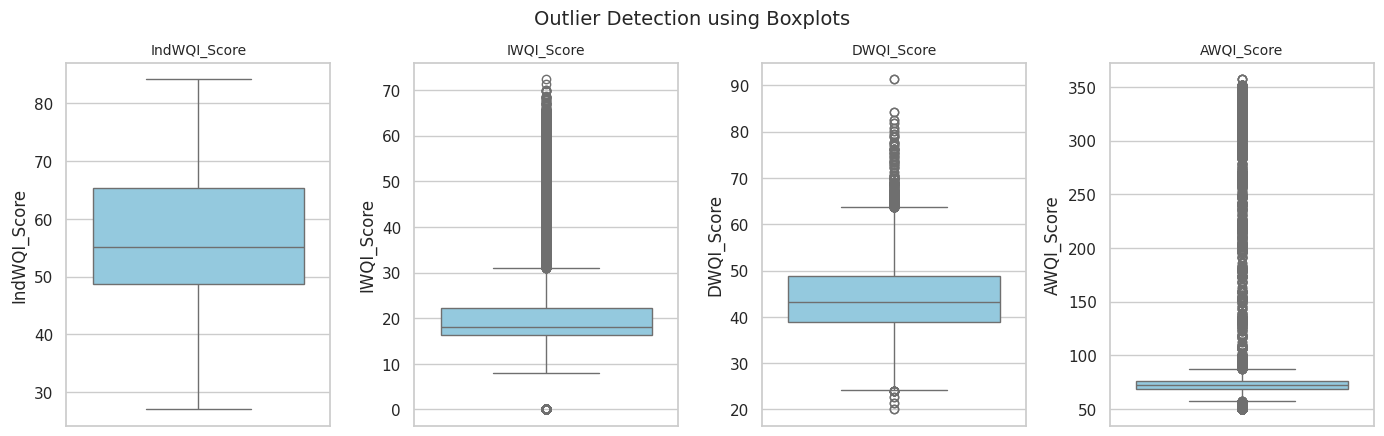

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to check for outliers
columns = ['IndWQI_Score',
           'IWQI_Score', 'DWQI_Score', 'AWQI_Score']

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create boxplots for each column
for i, col in enumerate(columns, 1):
    plt.subplot(2, 4, i)  # Adjust the layout: 2 rows, 4 columns
    sns.boxplot(y=data[col], color="skyblue")
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle("Outlier Detection using Boxplots", fontsize=14, y=1.02)
plt.show()

In [ ]:
# List of columns to check for outliers
columns = ['IndWQI_Score',
           'IWQI_Score', 'DWQI_Score', 'AWQI_Score']

# Make a copy to preserve original
data_cleaned = data.copy()

# Loop through each column to remove outliers
for col in columns:
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    data_cleaned = data_cleaned[(data_cleaned[col] >= lower_bound) & (data_cleaned[col] <= upper_bound)]

# Check the shape before and after
print(f"Original data shape: {data.shape}")
print(f"Cleaned data shape: {data_cleaned.shape}")

Original data shape: (29159, 22)
Cleaned data shape: (21103, 22)


In [ ]:
data = data.rename(columns={
    'Dissolved Oxygen': 'DO',
    'Ammonia-Total (as N)': 'Ammonia',
    'Total Hardness (as CaCO3)': 'Hardness',
    'Temperature': 'Temp',
    'Alkalinity-total (as CaCO3)': 'Alkalinity',
    'Conductivity @25°C': 'Conductivity',
    'BOD - 5 days (Total)': 'BOD',
    'True Colour': 'Color',
    'ortho-Phosphate (as P) - unspecified': 'orthophosphate',
    'pH': 'pH'  # stays the same but included for completeness
})

In [ ]:
data.columns

Index(['WaterbodyName', 'Years', 'SampleDate', 'Alkalinity', 'Ammonia', 'BOD',
       'Chloride', 'Conductivity', 'DO', 'orthophosphate', 'pH', 'Temp',
       'Hardness', 'Color', 'IndWQI', 'IndWQI_Score', 'IWQI', 'IWQI_Score',
       'DWQI', 'DWQI_Score', 'AWQI', 'AWQI_Score'],
      dtype='object')

In [ ]:
# Define the input features and output variables
input_features = [
    'Alkalinity', 'Ammonia', 'BOD',
       'Chloride', 'Conductivity', 'DO', 'orthophosphate', 'pH', 'Temp',
       'Hardness', 'Color' ]

Reg_output = ['IndWQI_Score','IWQI_Score','DWQI_Score', 'AWQI_Score']
# Class_output= ["CCME_WQI", "WAWQI_Quality", "IndWQI", "IWQI", "DWQI", "AWQI", "RWQI"]

In [ ]:
# Separate input and output variables
X = data[input_features]
y_reg = data[Reg_output]
# y_class = data[Class_output]

In [ ]:
y_reg = y_reg['DWQI_Score']

In [ ]:
y_reg

,DWQI_Score
0,35.893750
1,52.841607
2,52.518036
3,52.538929
4,52.630000
...,...
29154,38.992857
29155,40.508929
29156,39.347321
29157,46.061607


In [ ]:
X.head()

,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,orthophosphate,pH,Temp,Hardness,Color
0,314.0,0.033,1.2,27.3,711.0,52.50,0.019,7.80,10.4,370.0,24.0
1,14.0,0.033,1.2,10.0,71.0,61.85,0.019,7.42,17.8,13.4,35.0
2,17.0,0.033,1.2,11.5,79.0,61.80,0.019,7.67,18.1,15.8,29.0
3,18.0,0.033,1.2,11.3,78.0,62.40,0.019,7.63,17.8,15.9,31.0
4,19.0,0.033,1.2,10.5,76.0,66.05,0.019,7.33,20.1,15.4,23.0


In [ ]:
X.describe()

,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,orthophosphate,pH,Temp,Hardness,Color
count,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000
mean,139.858348,0.063573,1.276861,20.257858,363.039081,58.286184,0.068789,7.552057,10.850503,159.092110,58.137464
std,95.554543,0.441630,0.559890,19.127637,182.190019,26.946092,1.010133,0.581265,5.179973,99.937379,52.913140
min,0.000000,0.000000,0.000000,0.000000,33.000000,0.000000,-0.004000,4.700000,0.600000,0.000000,0.000000
25%,55.000000,0.033000,1.200000,15.600000,229.000000,49.400000,0.017000,7.200000,8.200000,71.000000,25.000000
50%,127.000000,0.033000,1.200000,18.600000,356.000000,54.900000,0.019000,7.700000,10.700000,152.000000,45.000000
75%,214.000000,0.033000,1.200000,22.000000,501.000000,75.000000,0.022000,8.000000,13.100000,237.000000,74.000000
max,442.000000,40.000000,16.000000,1260.000000,4200.000000,198.000000,70.000000,9.800000,637.000000,642.000000,953.000000


In [ ]:
y_reg.head()

,DWQI_Score
0,35.893750
1,52.841607
2,52.518036
3,52.538929
4,52.630000


In [ ]:
y_reg.describe()

,DWQI_Score
count,29159.000000
mean,44.084146
std,7.847075
min,20.000000
25%,38.932143
50%,43.174107
75%,48.814286
max,91.307143


In [ ]:
# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg= train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
# Standardize the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

# **1. Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np

# Define the model with default parameters
ridge = Ridge()

# Fit the model
ridge.fit(X_train_reg, y_train_reg)

# Predict
y_pred = ridge.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 4.295197011537434
MSE: 39.39179965726855
RMSE: 6.276288684984825
MAPE: 0.10054208771053949
R2 Score: 0.3606133326981118


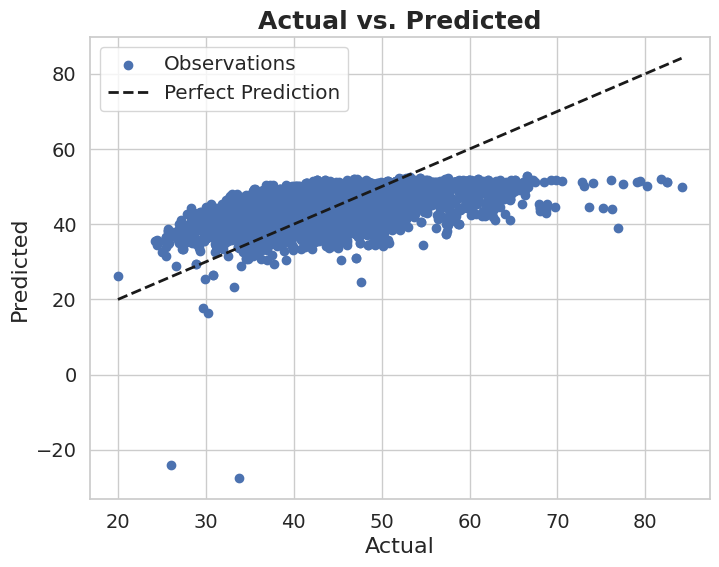

In [ ]:
import matplotlib.pyplot as plt

# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **2. Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the Lasso regression model with default parameters
lasso = Lasso(max_iter=10000)

# Fit the model
lasso.fit(X_train_reg, y_train_reg)

# Predict on test set
y_pred = lasso.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 4.338096672358109
MSE: 40.74336029693392
RMSE: 6.383052584534607
MAPE: 0.10188039267633998
R2 Score: 0.33867552176865867


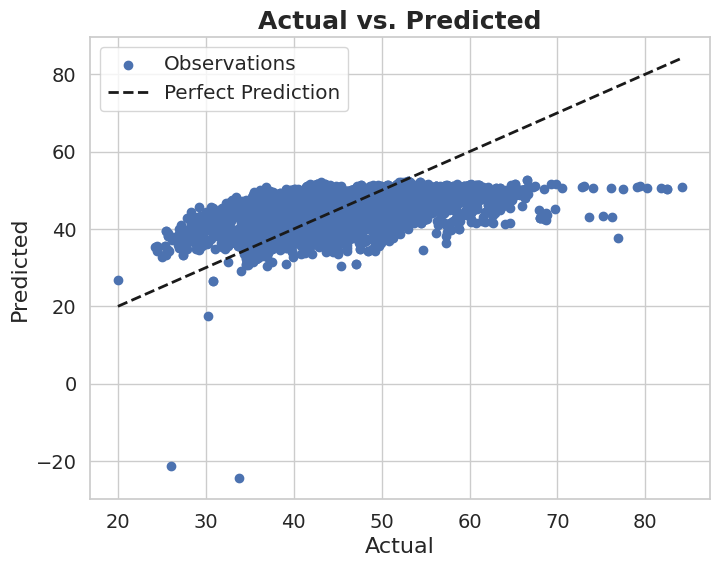

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **3. Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define model with default parameters
lr = LinearRegression()

# Fit model
lr.fit(X_train_reg, y_train_reg)

# Predict
y_pred = lr.predict(X_test_reg)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print("Model Parameters:", lr.get_params())
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

Model Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
MAE: 4.2951925633088335
MSE: 39.39171559186296
RMSE: 6.2762819879179235
MAPE: 0.10054194163621302
R2 Score: 0.36061469720290673


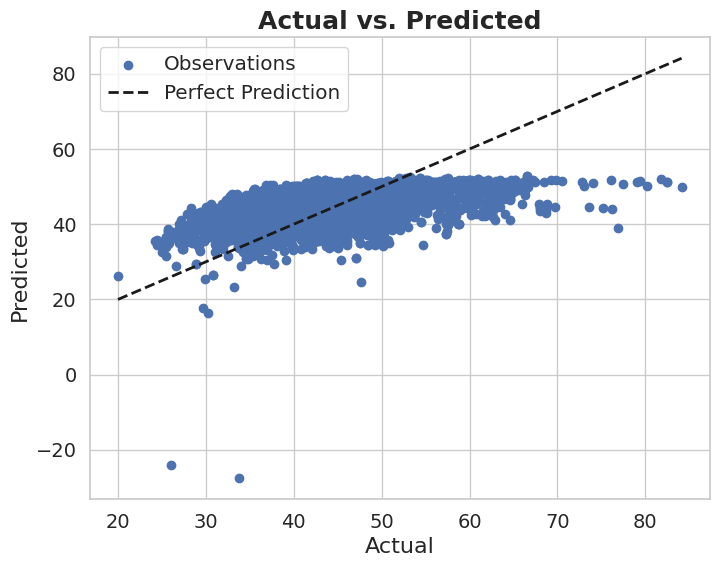

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **4. Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
dt = DecisionTreeRegressor(random_state=42)

# Fit model
dt.fit(X_train_reg, y_train_reg)

# Predict
y_pred = dt.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.059327625303257005
MSE: 0.11280066073960432
RMSE: 0.33585809613526413
MAPE: 0.0013566529007922148
R2 Score: 0.9981690798803999


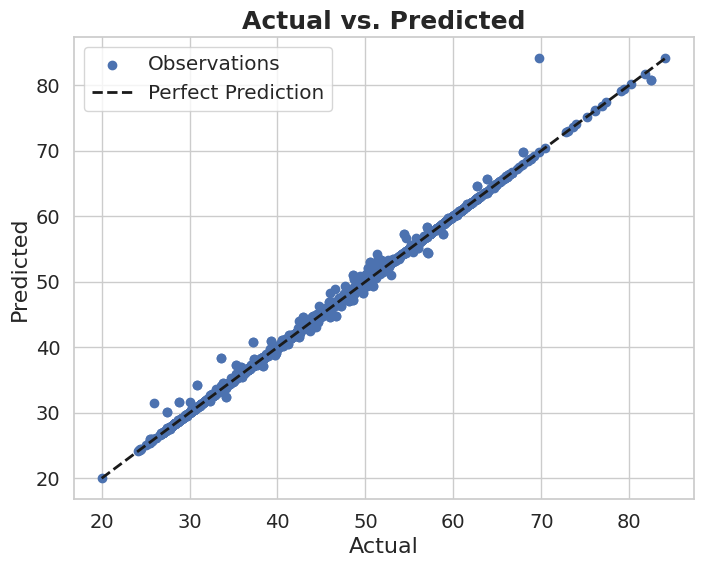

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **5. Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
rf = RandomForestRegressor(random_state=42)

# Fit the model
rf.fit(X_train_reg, y_train_reg)

# Predict
y_pred = rf.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.09200824936728014
MSE: 0.0892564358426267
RMSE: 0.2987581561106352
MAPE: 0.0020326605822182995
R2 Score: 0.9985512371725791


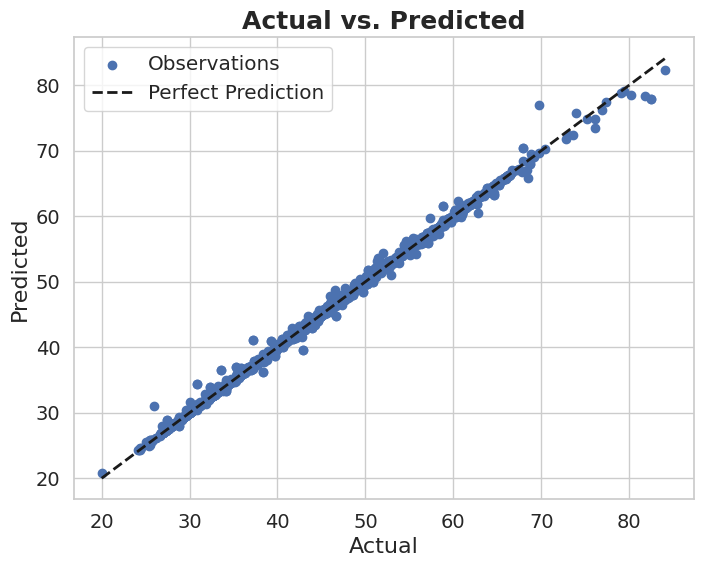

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **6. XGB Regressor**

In [ ]:
# !pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define and train the model with default parameters
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_reg, y_train_reg)

# Predict
y_pred = xgb_model.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.12381366607841662
MSE: 0.0433283218363253
RMSE: 0.2081545623721116
MAPE: 0.002828251153410232
R2 Score: 0.9992967178057426


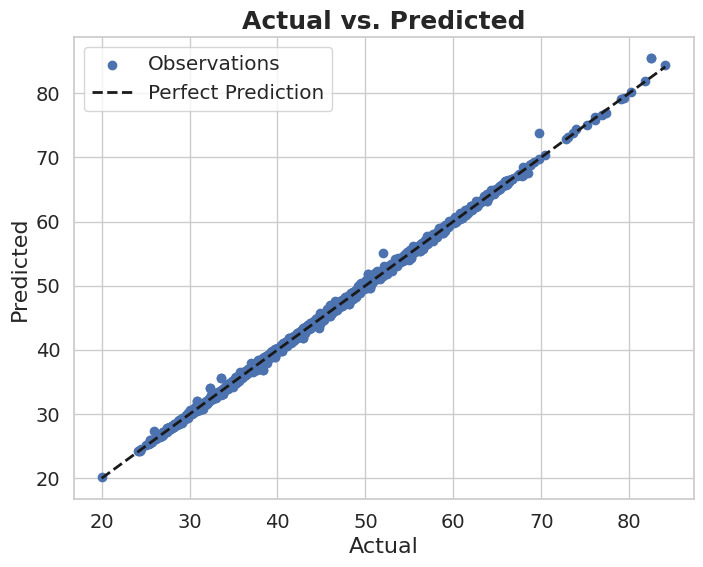

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **7. Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
gbr = GradientBoostingRegressor(random_state=42)

# Fit the model
gbr.fit(X_train_reg, y_train_reg)

# Predict
y_pred = gbr.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.28766057737003353
MSE: 0.17663467623928358
RMSE: 0.42027928361898065
MAPE: 0.006548983528878455
R2 Score: 0.9971329602111808


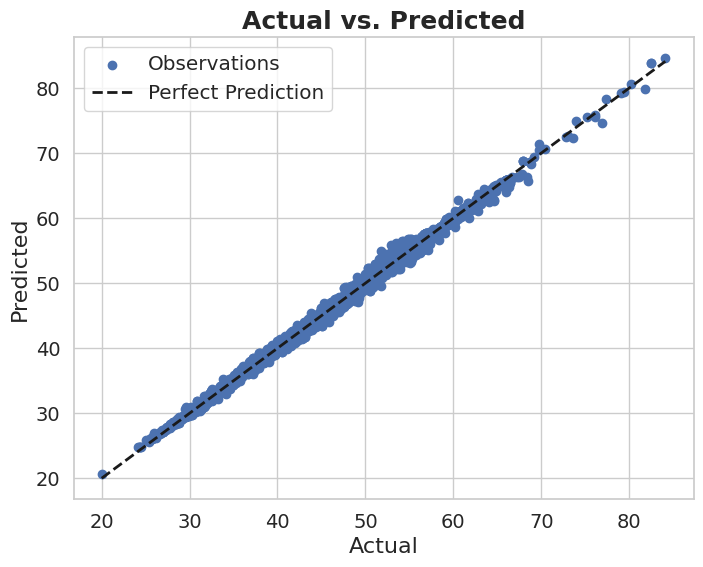

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **8. LightGBM Regressor**

In [ ]:
# !pip install lightgbm


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define LightGBM Regressor with default parameters
lgb_reg = lgb.LGBMRegressor(random_state=42)

# Fit model on training data
lgb_reg.fit(X_train_reg, y_train_reg)

# Predict on test data
y_pred = lgb_reg.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print("Best Parameters: Default parameters")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2497
[LightGBM] [Info] Number of data points in the train set: 23327, number of used features: 11
[LightGBM] [Info] Start training from score 44.085712
Best Parameters: Default parameters
MAE: 0.1505824149812467
MSE: 0.06472059956225915
RMSE: 0.2544024362349133
MAPE: 0.003406523485319972
R2 Score: 0.9989494897714769


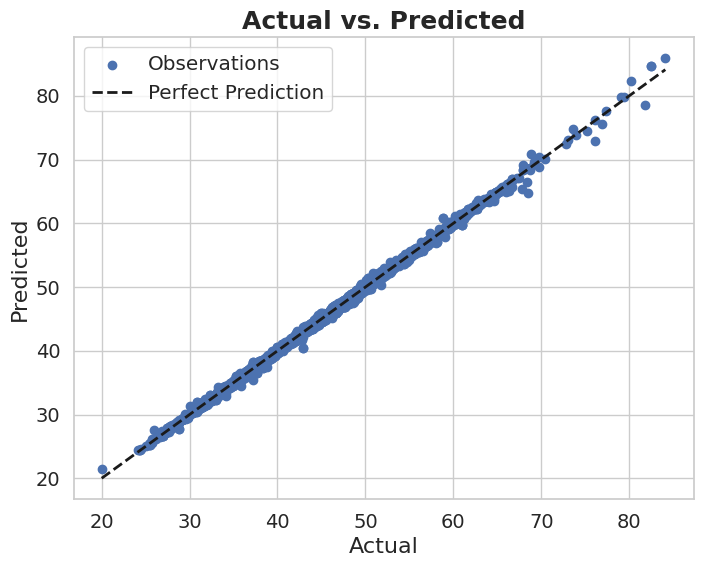

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **10 KNeighbors Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
knn = KNeighborsRegressor()

# Fit the model on training data
knn.fit(X_train_reg, y_train_reg)

# Predict on test set
y_pred = knn.predict(X_test_reg)

# Calculate metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print("Using default KNeighborsRegressor parameters:")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

Using default KNeighborsRegressor parameters:
MAE: 3.197007900144129
MSE: 23.181556922949714
RMSE: 4.814722933144722
MAPE: 0.0756219910202539
R2 Score: 0.6237293408071319


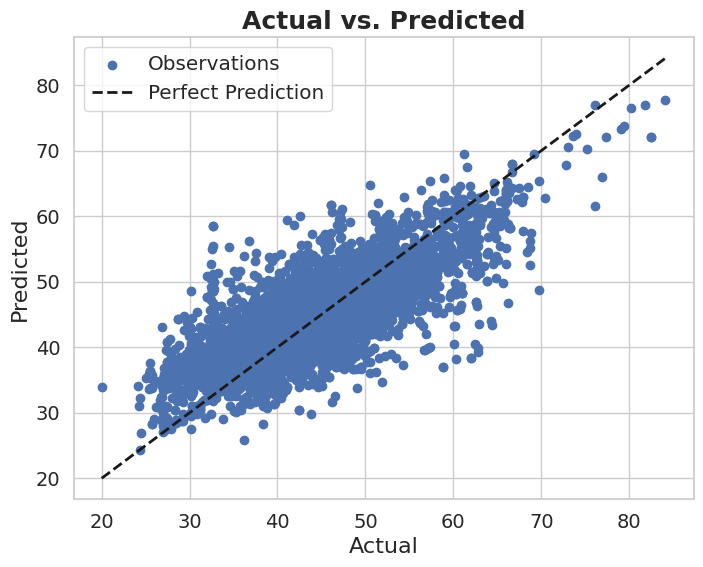

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **12. MLP Regressor**

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters (except max_iter and random_state)
mlp = MLPRegressor(max_iter=1000, random_state=42)

# Fit model
mlp.fit(X_train_reg, y_train_reg)

# Predict
y_pred = mlp.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.7769169736399482
MSE: 1.089526145654553
RMSE: 1.0438036911481743
MAPE: 0.01861812050886696
R2 Score: 0.9823153931206645


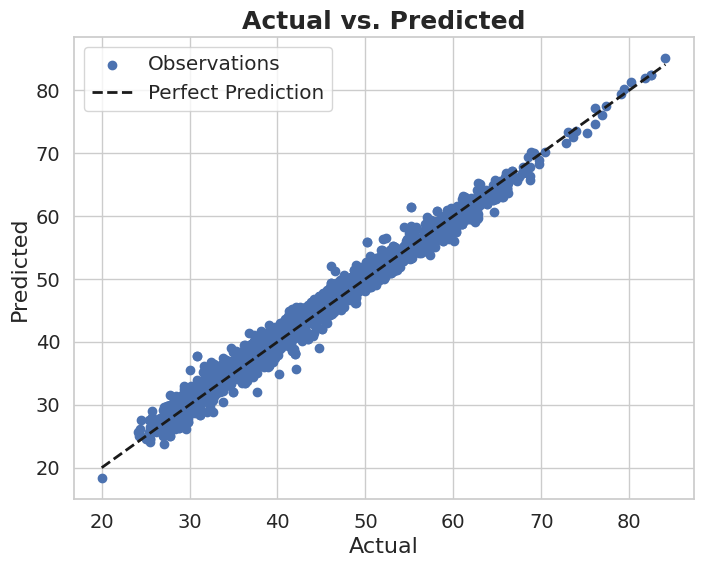

In [ ]:
# Plotting the first output variable
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()